In [1]:
import networkx as nx
import config as l
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data

ModuleNotFoundError: No module named 'config'

✅ 1. Analyse descriptive

✔️ Objectif : comprendre globalement vos données.

In [3]:
G = nx.read_graphml(l.PATH_DATA)

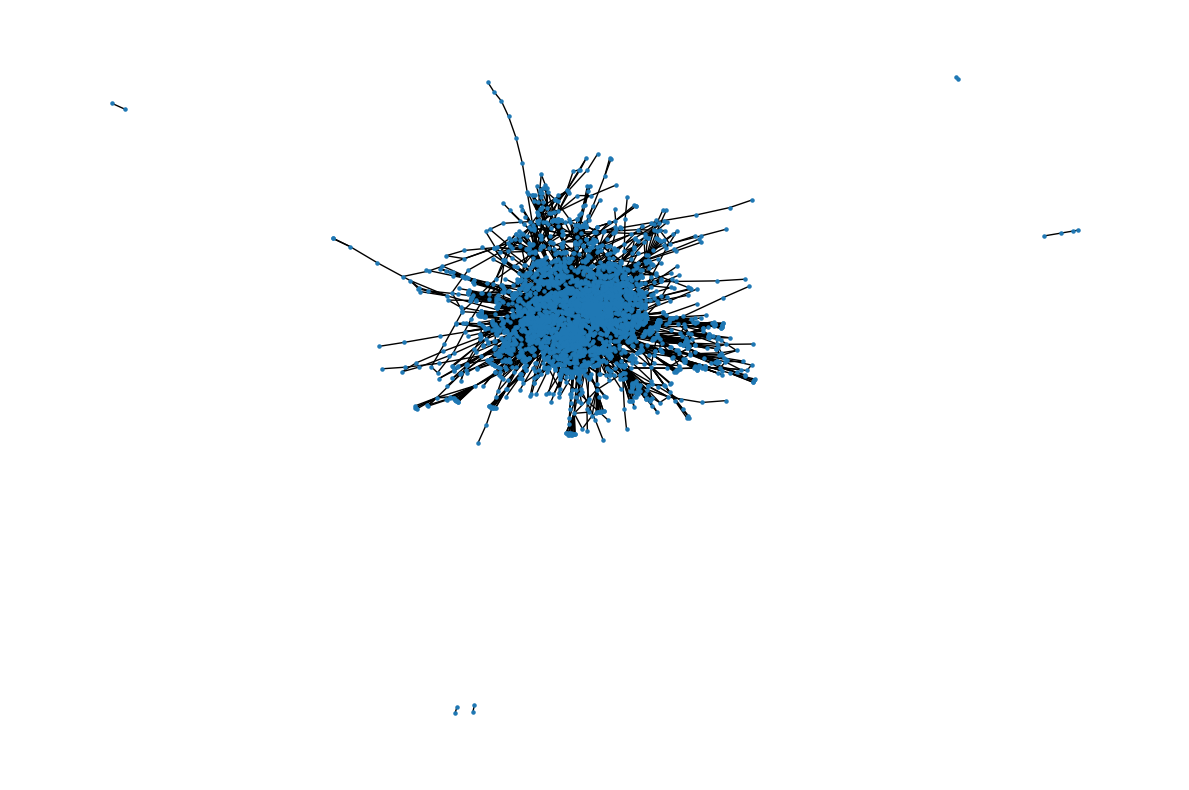

In [70]:
plt.figure(figsize=(12, 8))
nx.draw_networkx(G, with_labels=False, node_size=5)
plt.axis('off')
plt.tight_layout()
plt.show()

In [4]:
print("Nombre de nœuds :", len(G.nodes()))
print("Nombre d'arêtes :", len(G.edges()))

Nombre de nœuds : 3363
Nombre d'arêtes : 13547


In [6]:
node = list(G.nodes())[3]
print("Nœud :", node)
print("Attributs :", G.nodes[node])

Nœud : 3
Attributs : {'lon': -135.0, 'lat': -23.033333333333335, 'population': 10000, 'country': 'FRENCH_POLYNESIA', 'city_name': 'Gambier Island'}


In [9]:
df = pd.DataFrame([{'node': n, **G.nodes[n]} for n in G.nodes()])

In [11]:
print(df.describe())

               lon          lat    population
count  3363.000000  3363.000000  3.363000e+03
mean      0.696037    23.022150  3.380776e+05
std      96.474538    29.334014  1.262323e+06
min    -179.866667   -54.816667  6.370000e+02
25%     -81.440834    -0.966667  1.000000e+04
50%       6.108889    30.121944  1.506100e+04
75%      85.866667    45.796748  1.554095e+05
max     179.900000    78.245278  2.231547e+07


In [12]:
print(df["country"].value_counts())

country
USA                       650
CANADA                    243
AUSTRALIA                 207
BRAZIL                    105
CHINA                      93
                         ... 
WESTERN_SAHARA              1
TAJIKISTAN                  1
AFGHANISTAN                 1
FALKLAND_ISLANDS            1
SAINT_HELENA#ST_HELENA      1
Name: count, Length: 212, dtype: int64


In [13]:
print(df["population"].describe())

count    3.363000e+03
mean     3.380776e+05
std      1.262323e+06
min      6.370000e+02
25%      1.000000e+04
50%      1.506100e+04
75%      1.554095e+05
max      2.231547e+07
Name: population, dtype: float64


✅ 2. Analyse du graphe

✔️ Objectif : comprendre la structure du graphe

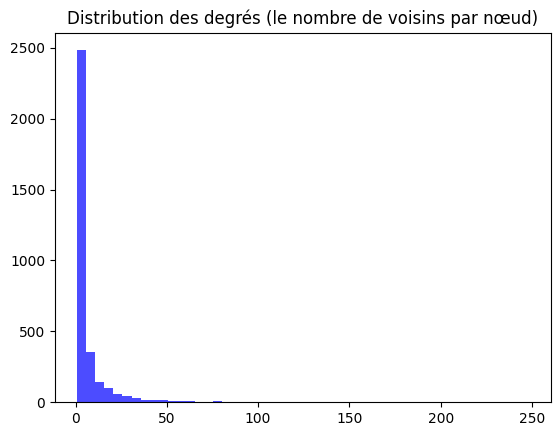

In [23]:
degrees = [G.degree(n) for n in G.nodes()]
plt.hist(degrees, bins=50, color='blue', alpha=0.7)
plt.title("Distribution des degrés (le nombre de voisins par nœud)")
plt.show()

In [20]:
# components : C’est un groupe de nœuds qui sont liés entre eux, mais pas aux autres
components = nx.connected_components(G)
sizes = [len(c) for c in components]
print("Taille des composantes :", sizes)

Taille des composantes : [3351, 2, 2, 2, 2, 4]


In [35]:
# Centralités : La centralité mesure l’importance d’un nœud dans un graphe
pr = nx.pagerank(G)

In [ ]:
pr_sorted = dict(sorted(pr.items(), key=lambda item: item[1], reverse=True))

for node, score in list(pr_sorted.items())[:10]:
    info = G.nodes[node]  
    print(f"Ville {info['city_name']} ({info['country']}), Population {info['population']} → PageRank : {score:.5f}")
    print('-' * 100)

Ville Paris (FRANCE), Population 2138551 → PageRank : 0.00643
----------------------------------------------------------------------------------------------------
Ville London (UNITED_KINGDOM), Population 346765 → PageRank : 0.00549
----------------------------------------------------------------------------------------------------
Ville Frankfurt (GERMANY), Population 10000 → PageRank : 0.00514
----------------------------------------------------------------------------------------------------
Ville Moscow (RUSSIA), Population 10381222 → PageRank : 0.00497
----------------------------------------------------------------------------------------------------
Ville Chicago (USA), Population 2696555 → PageRank : 0.00428
----------------------------------------------------------------------------------------------------
Ville Amsterdam (THE_NETHERLANDS), Population 741636 → PageRank : 0.00418
---------------------------------------------------------------------------------------------------

In [37]:
bet = nx.betweenness_centrality(G)

In [44]:
bet_sorted = dict(sorted(bet.items(), key=lambda item: item[1], reverse=True))

for node, score in list(bet_sorted.items())[:10]:
    info = G.nodes[node]  
    print(f"Ville {info['city_name']} ({info['country']}), Population {info['population']} → Betweenness centrality : {score:.5f}")
    print('-' * 100)

Ville Paris (FRANCE), Population 2138551 → Betweenness centrality : 0.09702
----------------------------------------------------------------------------------------------------
Ville London (UNITED_KINGDOM), Population 346765 → Betweenness centrality : 0.08572
----------------------------------------------------------------------------------------------------
Ville Singapore (SINGAPORE), Population 5638700 → Betweenness centrality : 0.07024
----------------------------------------------------------------------------------------------------
Ville Anchorage (USA), Population 291247 → Betweenness centrality : 0.07015
----------------------------------------------------------------------------------------------------
Ville New York (USA), Population 10000 → Betweenness centrality : 0.06982
----------------------------------------------------------------------------------------------------
Ville Frankfurt (GERMANY), Population 10000 → Betweenness centrality : 0.06679
-----------------------

✅ 3. Analyse géographique (spatiale)

✔️ Objectif : Corrélation entre population et proximité géographique

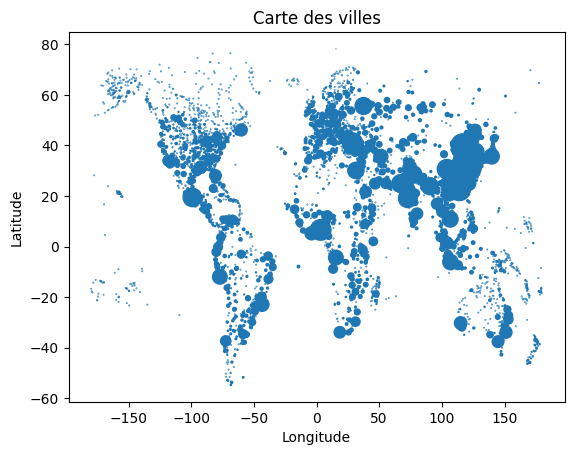

In [52]:
plt.scatter(df["lon"], df["lat"], s=df["population"]/70000)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Carte des villes")
plt.show()


✅ 4. Analyse par pays

In [60]:
df_country = df.groupby("country").agg(
    avg_population=("population", "mean"),
    city_count=("node", "count")
).reset_index()

In [61]:
df_country

,country,avg_population,city_count
0,AFGHANISTAN,10000.000000,1
1,ALBANIA,418495.000000,1
2,ALGERIA,175153.888889,27
3,AMERICAN_SAMOA,10500.000000,3
4,ANGOLA,592945.800000,5
...,...,...,...
207,WALLIS_AND_FUTUNA_ISLANDS,10000.000000,2
208,WESTERN_SAHARA,75000.000000,1
209,YEMEN,389220.888889,9
210,ZAMBIA,274433.700000,10


In [62]:
df

,node,lon,lat,population,country,city_name
0,0,-145.509722,-17.353889,10000,FRENCH_POLYNESIA,Anaa
1,1,-140.950000,-18.066667,10000,FRENCH_POLYNESIA,Hao Island
2,2,-149.600000,-17.550000,26357,FRENCH_POLYNESIA,Papeete
3,3,-135.000000,-23.033333,10000,FRENCH_POLYNESIA,Gambier Island
4,4,-143.657250,-16.584889,10000,FRENCH_POLYNESIA,Makemo
...,...,...,...,...,...,...
3358,3369,-69.616944,61.046667,10000,CANADA,Port Hope Simpson
3359,3370,146.820000,-6.100000,10000,PAPUA_NEW_GUINEA,Derim
3360,3364,-113.203900,54.743100,10000,CANADA,Williams Harbour
3361,3371,146.600000,-6.133333,10000,PAPUA_NEW_GUINEA,Yalumet


✅ 5. Matrice de corrélation

In [63]:
df = pd.DataFrame([
    {**G.nodes[n], "node": n} for n in G.nodes()
])

df_num = df[["lon", "lat", "population"]]

In [64]:
df_num

,lon,lat,population
0,-145.509722,-17.353889,10000
1,-140.950000,-18.066667,10000
2,-149.600000,-17.550000,26357
3,-135.000000,-23.033333,10000
4,-143.657250,-16.584889,10000
...,...,...,...
3358,-69.616944,61.046667,10000
3359,146.820000,-6.100000,10000
3360,-113.203900,54.743100,10000
3361,146.600000,-6.133333,10000


In [68]:
corr = df_num.corr()

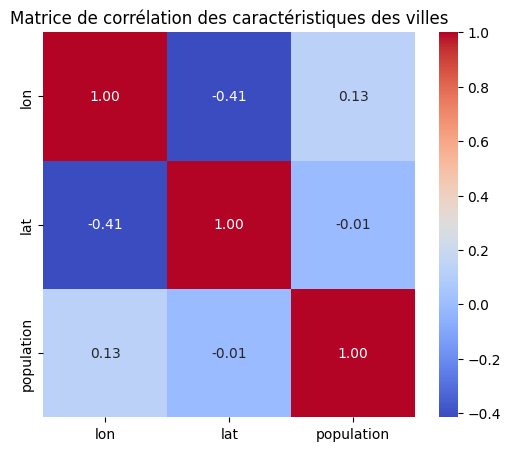

In [69]:
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matrice de corrélation des caractéristiques des villes")
plt.show()

✅ 6. Update data

In [71]:
max_cc = max(nx.connected_components(G), key=len)
G_large = G.subgraph(max_cc).copy()

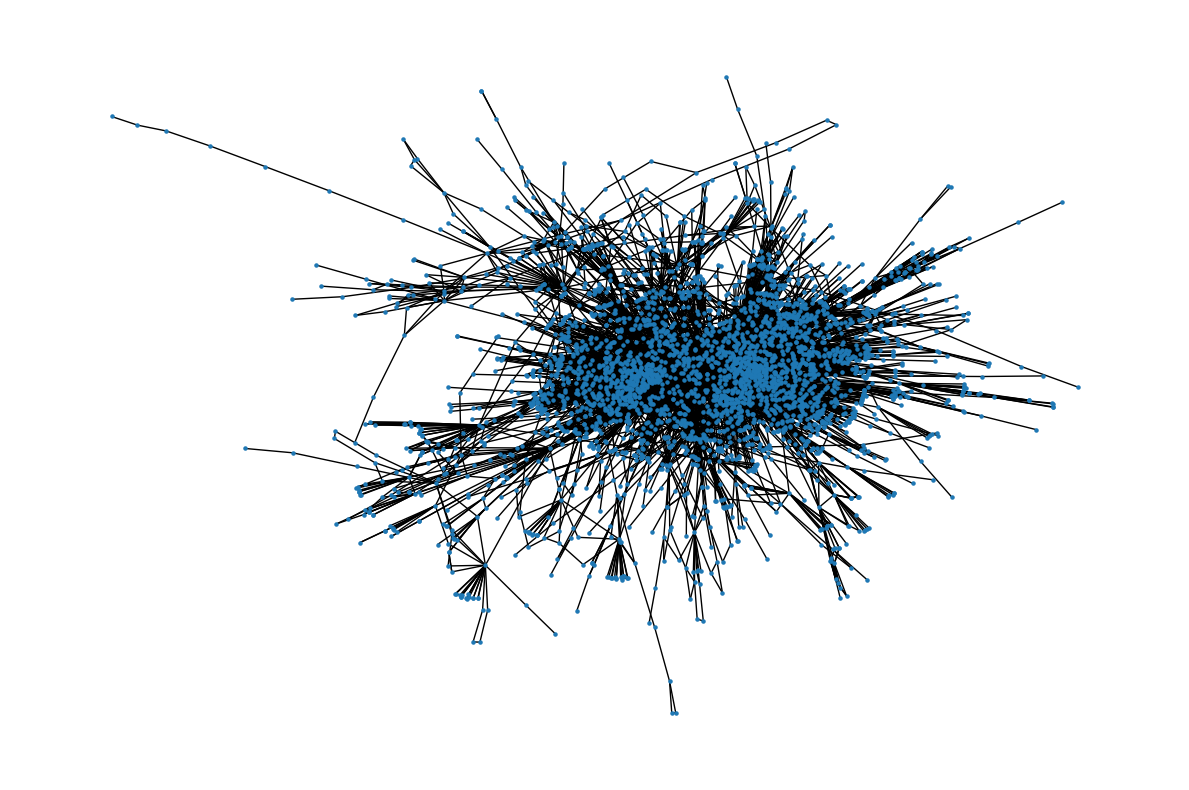

In [72]:
plt.figure(figsize=(12, 8))
nx.draw_networkx(G_large, with_labels=False, node_size=5)
plt.axis('off')
plt.tight_layout()
plt.show()

In [82]:
df = pd.DataFrame([
    {**G_large.nodes[n], "node": n} for n in G_large.nodes()
])

df_num = df[["lon", "lat", "population"]]

In [83]:
X = df_num[['lon', 'lat', 'population']].values

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [84]:
X

array([[-1.51641202, -1.38027336, -0.2604261 ],
       [-1.4690877 , -1.40461948, -0.2604261 ],
       [-1.55886408, -1.38697186, -0.24748792],
       ...,
       [ 1.51761145, -0.99587779, -0.2604261 ],
       [ 1.51532812, -0.99701635, -0.2604261 ],
       [ 1.52207432, -0.99246213, -0.2604261 ]], shape=(3351, 3))

In [85]:
x = torch.tensor(X, dtype=torch.float)

In [86]:
x

tensor([[-1.5164, -1.3803, -0.2604],
        [-1.4691, -1.4046, -0.2604],
        [-1.5589, -1.3870, -0.2475],
        ...,
        [ 1.5176, -0.9959, -0.2604],
        [ 1.5153, -0.9970, -0.2604],
        [ 1.5221, -0.9925, -0.2604]])

In [ ]:
mapping = {node: i for i, node in enumerate(G_large.nodes())}

In [ ]:
G_int = nx.relabel_nodes(G_large, mapping)

In [ ]:
edge_index = torch.tensor(list(G_int.edges), dtype=torch.long).t().contiguous()

In [94]:
edge_index

tensor([[   0,    0,    1,  ..., 3346, 3348, 3349],
        [   1,    2,    2,  ..., 3348, 3349, 3350]])

In [95]:
print(list(G_int.edges)[:5])

[(0, 1), (0, 2), (1, 2), (1, 3), (1, 4)]


In [97]:
data = Data(x=x, edge_index=edge_index)

In [98]:
data

Data(x=[3351, 3], edge_index=[2, 13540])

In [ ]:
torch.save(data,l.PATH_DATA_SAVE)